# Individual Structure (IS) aggregation

Group-level analyses in **MDMP** live under `mdmp.group_analysis`:

- **`vts`** — Virtual Typical Subject: summarize multi-subject *time series* into one representative series.
- **`is`** — Individual Structure aggregation: summarize subject-specific *DAGs* into one global DAG by edge voting (threshold `τ`) and acyclic repair.

Below: **eight** subject DAGs over **four** nodes, aggregation at **tau = 0.5** (package default), and a graph plot. For **VTS vs IS** on simulated multi-individual CSVs, see `notebooks/04-is-vs-vts-multi-individual.ipynb`.

In [6]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

from mdmp import aggregate_individual_structures, plot_dag

## Synthetic subject DAGs (4 nodes, 8 subjects)

Convention: `adj[i, j] == 1` means directed edge **parent i to child j** (same as MDM). Eight diverse acyclic graphs illustrate richer disagreement and possible cycles after thresholding.


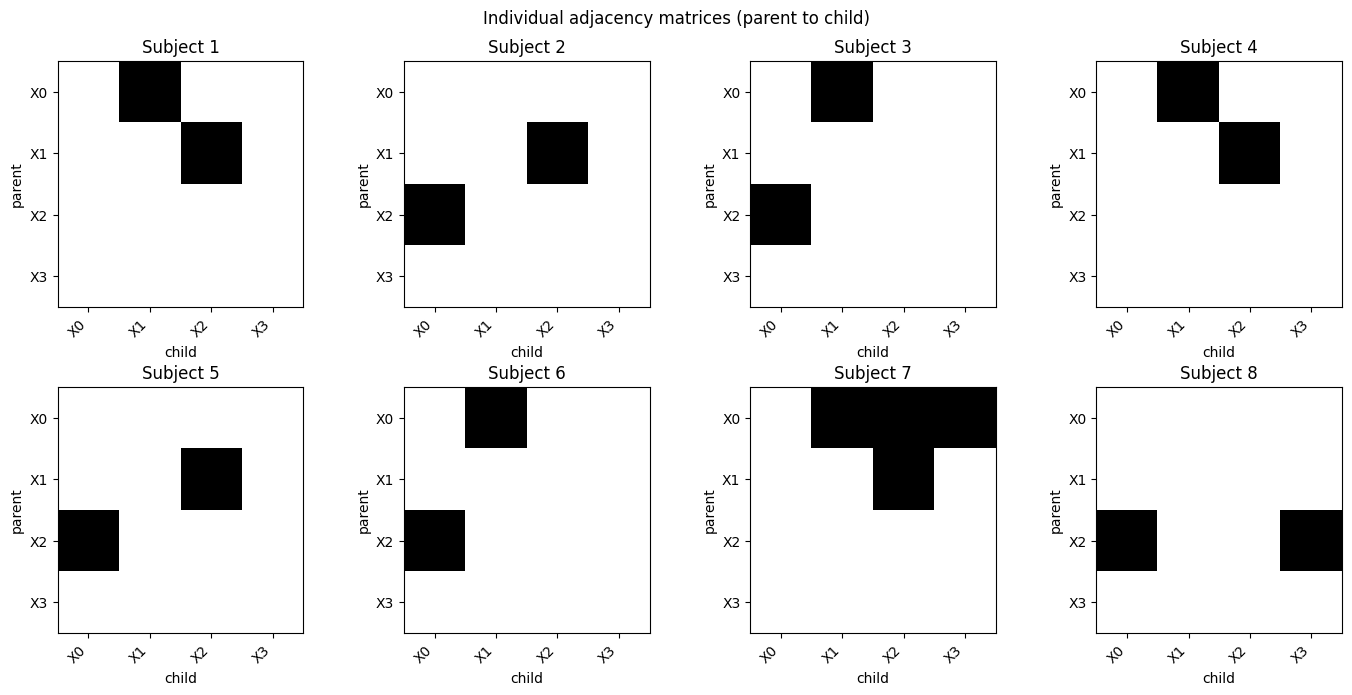

In [7]:
names = ["X0", "X1", "X2", "X3"]
n = 4

def dag():
    return np.zeros((n, n), dtype=int)

# Three rotations on {0,1,2} (each is a DAG); repeating patterns + extras ->
# majority voting can close a 3-cycle on X0,X1,X2 while X3 carries other edges.
g1 = dag()
g1[0, 1] = g1[1, 2] = 1
g2 = dag()
g2[1, 2] = g2[2, 0] = 1
g3 = dag()
g3[2, 0] = g3[0, 1] = 1
g4 = dag()
g4[0, 1] = g4[1, 2] = 1  # same as g1
g5 = dag()
g5[1, 2] = g5[2, 0] = 1  # same as g2
g6 = dag()
g6[2, 0] = g6[0, 1] = 1  # same as g3
g7 = dag()
g7[0, 1] = g7[0, 2] = g7[0, 3] = g7[1, 2] = 1  # star + 1->2 for extra 1->2 vote
g8 = dag()
g8[2, 0] = g8[2, 3] = 1  # extra vote for 2->0; 2->3 edge

subject_dags = [g1, g2, g3, g4, g5, g6, g7, g8]
S = len(subject_dags)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for ax, adj, s in zip(axes, subject_dags, range(1, S + 1)):
    ax.imshow(adj, cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticklabels(names)
    ax.set_xlabel("child")
    ax.set_ylabel("parent")
    ax.set_title(f"Subject {s}")
plt.suptitle("Individual adjacency matrices (parent to child)")
plt.tight_layout()
plt.show()


## Aggregation (`tau = 0.5`)

Default threshold: keep edges that appear in **more than half** of subjects. The pooled graph may contain a **directed cycle**; the implementation removes the **lowest-frequency** edge on each detected cycle until the graph is acyclic.


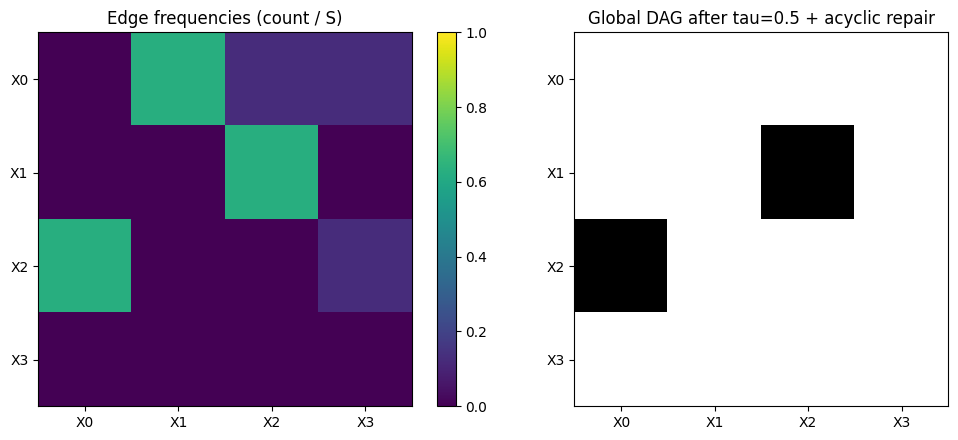

Edges removed for acyclicity:
{'parent_idx': 0, 'child_idx': 1, 'parent_name': 'X0', 'child_name': 'X1', 'frequency': 0.625}


In [8]:
tau = 0.5
result = aggregate_individual_structures(subject_dags, tau=tau, node_names=names)

freq = result.metadata["edge_frequencies"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axes[0].imshow(freq, cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Edge frequencies (count / S)")
axes[0].set_xticks(range(n))
axes[0].set_yticks(range(n))
axes[0].set_xticklabels(names)
axes[0].set_yticklabels(names)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(result.adj_mat, cmap="Greys", vmin=0, vmax=1)
axes[1].set_title(f"Global DAG after tau={tau} + acyclic repair")
axes[1].set_xticks(range(n))
axes[1].set_yticks(range(n))
axes[1].set_xticklabels(names)
axes[1].set_yticklabels(names)
plt.tight_layout()
plt.show()

print("Edges removed for acyclicity:")
for e in result.metadata["edges_removed_for_acyclicity"]:
    print(e)


## Global DAG (same interface as MDM for `plot_dag`)

`ISAggregationResult` exposes `adj_mat` and `node_names`, so `plot_dag` works the same as for a fitted `MDM`.

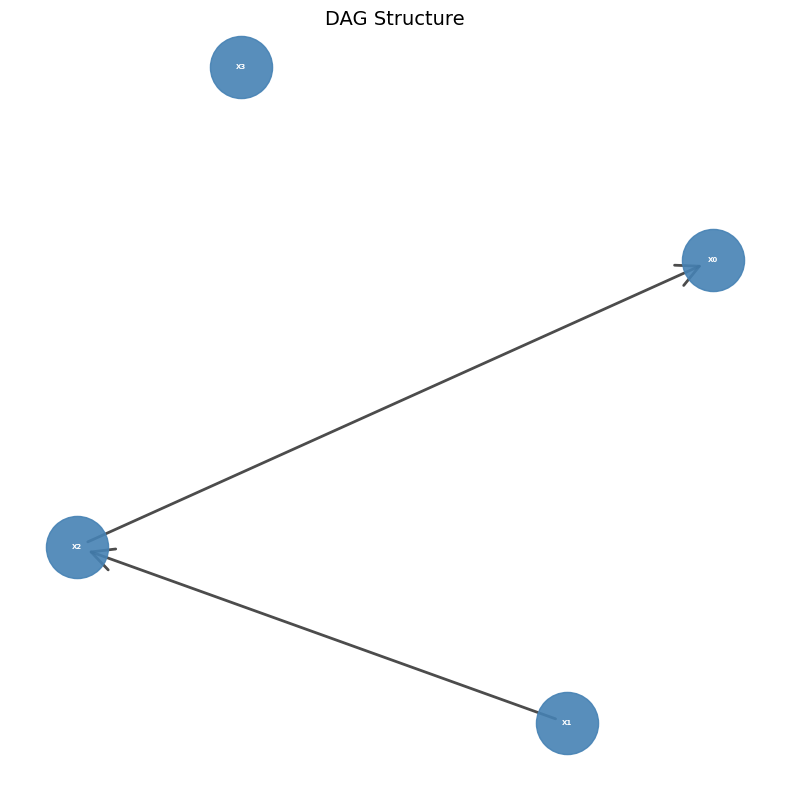

In [9]:
fig = plot_dag(result, plot_type="graph", layout_seed=0)
# fig